In [10]:
kaggle = '../../Data/kaggle.json'

In [11]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

The syntax of the command is incorrect.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


In [12]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [13]:
from zipfile import ZipFile
import os

file_name = 'handwritten-digits-0-9.zip'

extract_path = 'handwritten_digits'
os.makedirs(extract_path, exist_ok=True)

with ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print(f'Extracted all files to {extract_path}/')

Extracted all files to handwritten_digits/


In [14]:
data_0 = os.listdir(os.path.join(extract_path, '0'))
data_1 = os.listdir(os.path.join(extract_path, '1'))
data_2 = os.listdir(os.path.join(extract_path, '2'))
data_3 = os.listdir(os.path.join(extract_path, '3'))
data_4 = os.listdir(os.path.join(extract_path, '4'))
data_5 = os.listdir(os.path.join(extract_path, '5'))
data_6 = os.listdir(os.path.join(extract_path, '6'))
data_7 = os.listdir(os.path.join(extract_path, '7'))
data_8 = os.listdir(os.path.join(extract_path, '8'))
data_9 = os.listdir(os.path.join(extract_path, '9'))

In [15]:
len(data_0)

2236

In [16]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [17]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from sklearn.utils import shuffle

## Load dan Preprocess Data Gambar

Memuat gambar dari setiap folder digit dan mengubahnya menjadi array numpy

In [18]:
def load_images_from_folder(folder, label, img_size=(28, 28)):
    images = []
    labels = []
    files = os.listdir(folder)
    
    for file in files[:500]:  # Membatasi jumlah gambar per kelas untuk efisiensi
        img_path = os.path.join(folder, file)
        try:
            img = image.load_img(img_path, target_size=img_size, color_mode='grayscale')
            img_array = image.img_to_array(img)
            img_array = img_array / 255.0  # Normalisasi
            images.append(img_array)
            labels.append(label)
        except:
            continue
    
    return images, labels

In [19]:
all_images = []
all_labels = []

for digit in range(10):
    folder_path = os.path.join(extract_path, str(digit))
    images, labels = load_images_from_folder(folder_path, digit)
    all_images.extend(images)
    all_labels.extend(labels)
    print(f'Loaded {len(images)} images for digit {digit}')

print(f'\nTotal images loaded: {len(all_images)}')

Loaded 500 images for digit 0
Loaded 500 images for digit 1
Loaded 500 images for digit 2
Loaded 500 images for digit 3
Loaded 500 images for digit 4
Loaded 500 images for digit 5
Loaded 500 images for digit 6
Loaded 500 images for digit 7
Loaded 500 images for digit 8
Loaded 500 images for digit 9

Total images loaded: 5000


In [20]:
X = np.array(all_images)
y = np.array(all_labels)

# Shuffle data
X, y = shuffle(X, y, random_state=42)

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')

Shape X: (5000, 28, 28, 1)
Shape y: (5000,)


## Visualisasi Beberapa Contoh Gambar

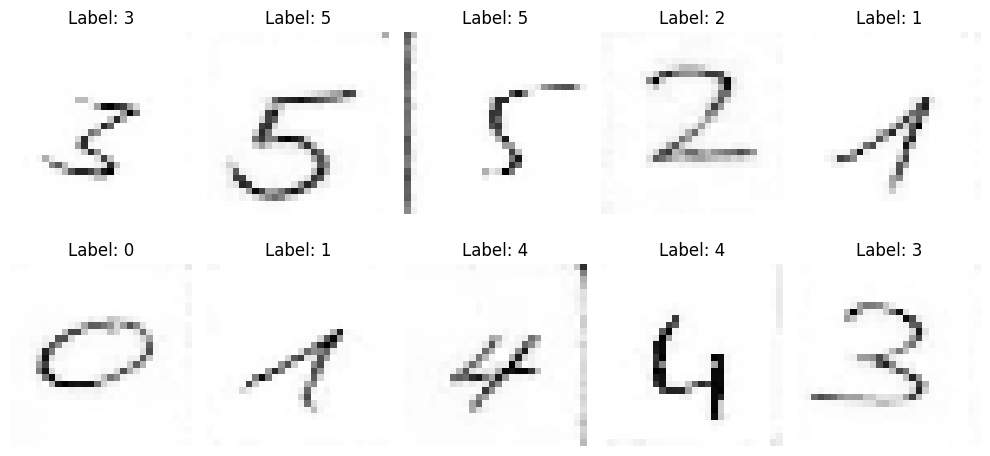

In [21]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {y[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Preprocessing Data untuk MLP

Flatten gambar dan convert label ke one-hot encoding

In [22]:
# Flatten gambar dari (28, 28, 1) menjadi (784,)
X_flatten = X.reshape(X.shape[0], -1)
print(f'Shape X setelah flatten: {X_flatten.shape}')

# One-hot encoding untuk label (multi-class classification)
y_encoded = to_categorical(y, num_classes=10)
print(f'Shape y setelah one-hot encoding: {y_encoded.shape}')

Shape X setelah flatten: (5000, 784)
Shape y setelah one-hot encoding: (5000, 10)


## Split Data Training dan Testing

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_flatten, y_encoded, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (4000, 784)
X_test shape: (1000, 784)
y_train shape: (4000, 10)
y_test shape: (1000, 10)


## Membangun Model Multi-Layer Perceptron (MLP)

Arsitektur model:
- Input layer: 784 nodes (28x28 pixels)
- Hidden layer 1: 128 nodes dengan ReLU activation
- Dropout: 0.3
- Hidden layer 2: 64 nodes dengan ReLU activation  
- Dropout: 0.3
- Hidden layer 3: 32 nodes dengan ReLU activation
- Dropout: 0.3
- Output layer: 10 nodes dengan Softmax activation (multi-class)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# Hidden layer 1
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

# Hidden layer 2
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Hidden layer 3
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

# Output layer (10 kelas untuk digit 0-9)
model.add(Dense(10, activation='softmax'))

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [25]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

## Setup Early Stopping

Untuk mencegah overfitting dengan menghentikan training jika val_loss tidak membaik

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
print('Early stopping callback telah diatur')

Early stopping callback telah diatur


## Training Model

In [27]:
history = model.fit(X_train, y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.2, 
                    callbacks=[early_stop], 
                    verbose=1)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1103 - loss: 2.3579 - val_accuracy: 0.0887 - val_loss: 2.3144
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1163 - loss: 2.3045 - val_accuracy: 0.0763 - val_loss: 2.3040
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1109 - loss: 2.3021 - val_accuracy: 0.0775 - val_loss: 2.3049
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1106 - loss: 2.3020 - val_accuracy: 0.0775 - val_loss: 2.3053
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1106 - loss: 2.3021 - val_accuracy: 0.0775 - val_loss: 2.3059
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1106 - loss: 2.3020 - val_accuracy: 0.0775 - val_loss: 2.3061
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1106 - loss: 2.3020 - val_accuracy: 0.0775 - val_loss: 2.3063
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1106 - loss: 2.3019 - val_accu

## Evaluasi Model pada Test Data

In [28]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'\nTest Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0850 - loss: 2.3041

Test Loss: 2.3041
Test Accuracy: 0.0850 (8.50%)


## Visualisasi Training History

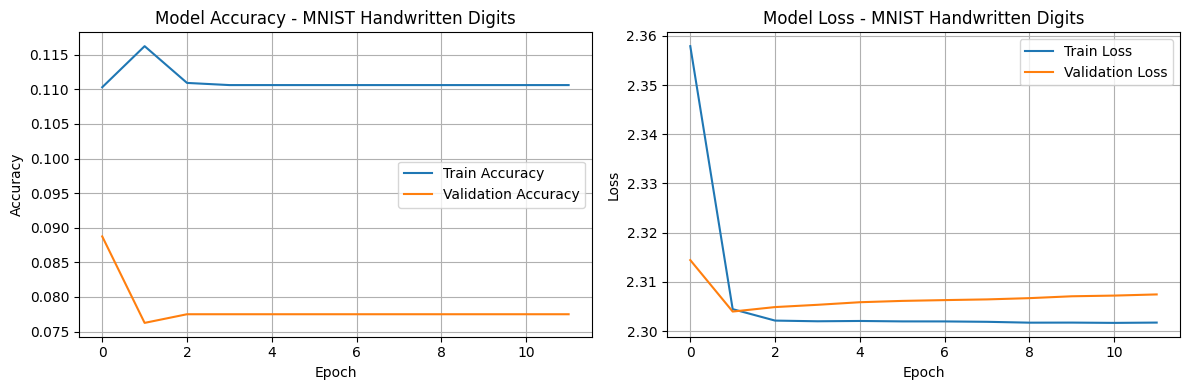

In [29]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy - MNIST Handwritten Digits')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss - MNIST Handwritten Digits')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Prediksi pada Sample Data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


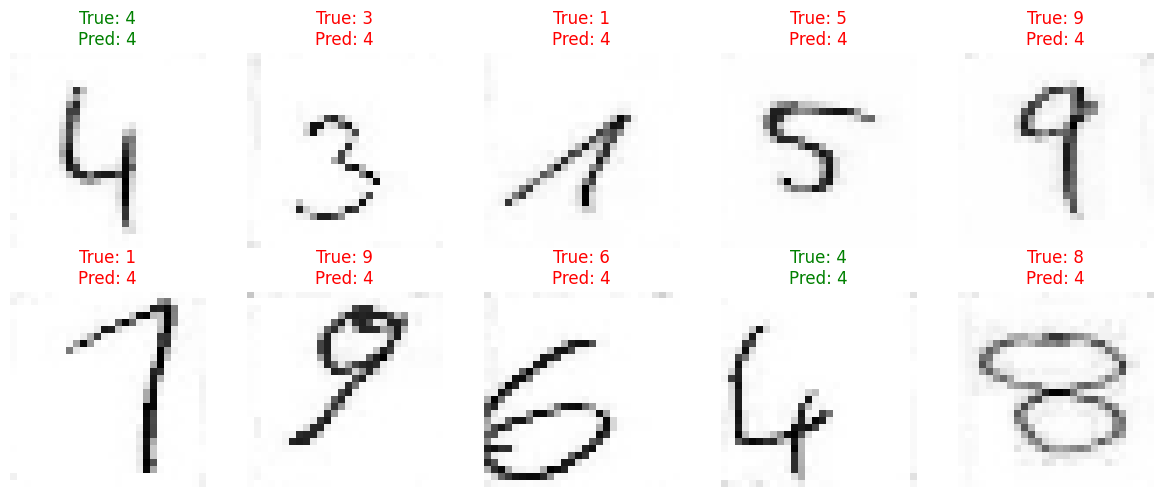

In [30]:
predictions = model.predict(X_test[:10])
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[:10], axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f'True: {true_labels[i]}\nPred: {predicted_labels[i]}', color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Confusion Matrix dan Classification Report

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


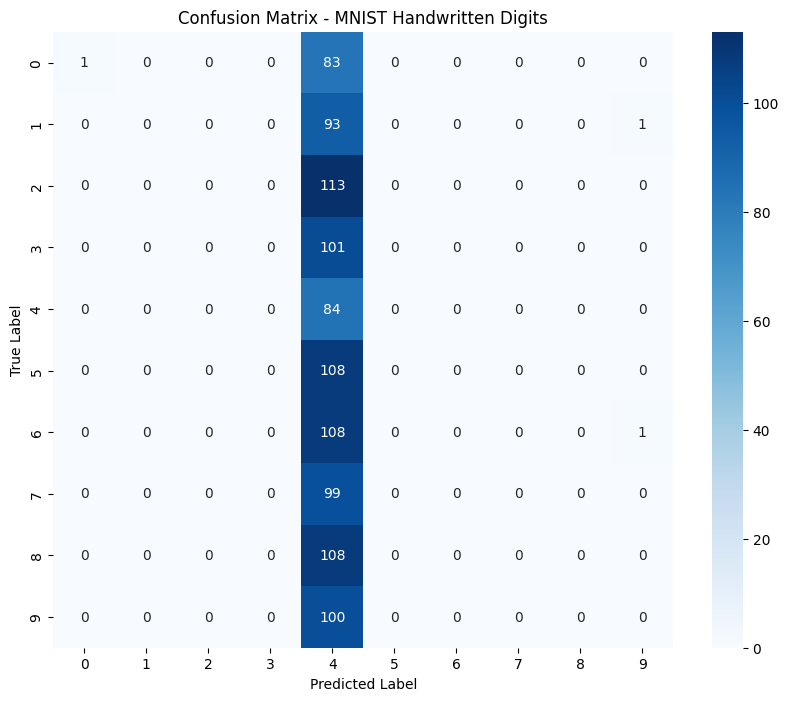


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.02        84
           1       0.00      0.00      0.00        94
           2       0.00      0.00      0.00       113
           3       0.00      0.00      0.00       101
           4       0.08      1.00      0.16        84
           5       0.00      0.00      0.00       108
           6       0.00      0.00      0.00       109
           7       0.00      0.00      0.00        99
           8       0.00      0.00      0.00       108
           9       0.00      0.00      0.00       100

    accuracy                           0.09      1000
   macro avg       0.11      0.10      0.02      1000
weighted avg       0.09      0.09      0.02      1000



c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Prediksi semua test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MNIST Handwritten Digits')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes))

## Perbandingan dengan Dataset Tabular (Titanic)

### Perbedaan Proses:

**Dataset Citra (MNIST):**
1. Data berupa gambar (28x28 pixels) yang di-flatten menjadi vektor 784 dimensi
2. Preprocessing: normalisasi pixel values (0-255 → 0-1)
3. Label menggunakan one-hot encoding untuk multi-class (10 kelas)
4. Loss function: categorical_crossentropy
5. Output activation: softmax

**Dataset Tabular (Titanic):**
1. Data berupa fitur numerik dan kategorikal
2. Preprocessing: scaling dengan RobustScaler, encoding kategorikal
3. Label binary (0 atau 1)
4. Loss function: binary_crossentropy
5. Output activation: sigmoid

### Observasi Performa:
- Model MLP pada citra membutuhkan lebih banyak parameter karena dimensi input yang besar (784 vs 7)
- Dropout sangat penting untuk mencegah overfitting pada data citra
- Training time lebih lama pada data citra karena ukuran data dan kompleksitas
- Akurasi pada MNIST umumnya lebih tinggi karena dataset yang lebih terstruktur

## Simpan Model

In [32]:
model.save('../../Model/mnist_mlp_model.h5')
print('Model berhasil disimpan ke ../../Model/mnist_mlp_model.h5')

Model berhasil disimpan ke ../../Model/mnist_mlp_model.h5
